# 薄层起伏模型：Gaussian 初始模型

本Notebook包含真实保存结果与可执行复绘代码。配套FWI Python脚本已在四张A30完成；下面CPU单元实际执行，图像嵌入输出。整体目录可移动，保持results/相对路径。

100 epochs，训练77.10s；RMSE 84.704→67.714m/s。

本例仍有恢复局限，不能仅凭loss下降判断正确重建。


In [23]:
from pathlib import Path
import json, numpy as np
from IPython.display import display, Image
ROOT = Path.cwd()
assert (ROOT / 'case_manifest.json').is_file(), 'Open from delivered folder'
CASE = 'layered'
RESULTS = ROOT / 'results' / CASE
summary = json.loads((RESULTS / 'summary.json').read_text())
print(json.dumps({k: summary[k] for k in ('status','completed_epochs','training_seconds','gpu_memory','initial','final','quality_checks')},ensure_ascii=False,indent=2))

{
  "status": "COMPLETED",
  "completed_epochs": 100,
  "training_seconds": 77.09515070100315,
  "gpu_memory": {
    "2": {
      "allocated_MiB": 67.56396484375,
      "reserved_MiB": 92.0
    },
    "0": {
      "allocated_MiB": 61.78759765625,
      "reserved_MiB": 72.0
    },
    "1": {
      "allocated_MiB": 61.78759765625,
      "reserved_MiB": 72.0
    },
    "3": {
      "allocated_MiB": 61.78759765625,
      "reserved_MiB": 72.0
    }
  },
  "initial": {
    "epoch": 0,
    "fixed_model_normalized_mse": 0.04723405838012695,
    "rmse_m_s": 84.7042435842085,
    "subsurface_rmse_m_s": 94.7022233184953,
    "elapsed_seconds": 0.41600409398961347
  },
  "final": {
    "epoch": 100,
    "fixed_model_normalized_mse": 7.838547389837913e-05,
    "rmse_m_s": 67.71385053427731,
    "subsurface_rmse_m_s": 75.70638640645225,
    "elapsed_seconds": 0.35909691199776717
  },
  "quality_checks": {
    "loss_improved": true,
    "rmse_improved": true
  }
}


## 梯度正确性

2/4/6/8阶full/boundary、4阶内部方向中心有限差分，以及相同四炮的单卡/四卡比较。阈值和数值全部保留。

In [24]:
checks = json.loads((RESULTS / 'numerical_checks.json').read_text())
assert checks['status'] == 'PASSED'
print(json.dumps(checks,ensure_ascii=False,indent=2))
print((RESULTS / 'gradients' / 'gradient_manifest.json').read_text())

{
  "status": "PASSED",
  "checks": [
    {
      "check": "full_vs_boundary",
      "accuracy": 2,
      "record_relative_l2": 0.0,
      "gradient_relative_l2": 5.534903087416326e-07,
      "record_tolerance": 1e-06,
      "gradient_tolerance": 0.001
    },
    {
      "check": "full_vs_boundary",
      "accuracy": 4,
      "record_relative_l2": 0.0,
      "gradient_relative_l2": 7.268850089120318e-07,
      "record_tolerance": 1e-06,
      "gradient_tolerance": 0.001
    },
    {
      "check": "full_vs_boundary",
      "accuracy": 6,
      "record_relative_l2": 0.0,
      "gradient_relative_l2": 5.628268240572121e-07,
      "record_tolerance": 1e-06,
      "gradient_tolerance": 0.001
    },
    {
      "check": "full_vs_boundary",
      "accuracy": 8,
      "record_relative_l2": 0.0,
      "gradient_relative_l2": 4.35495121577788e-07,
      "record_tolerance": 1e-06,
      "gradient_tolerance": 0.001
    },
    {
      "check": "model_directional_derivative",
      "accuracy": 4,
 

## 观测系统、模型、收敛和中间梯度

CPU重新绘图，未平滑结果。梯度既有独立归一化图，也有共同原始色标图。

In [25]:
from render_scalar3d import render_case
figure_files = render_case(RESULTS)
print('Re-rendered:',figure_files)

Re-rendered: ['convergence.png', 'gradients_normalized.png', 'shot_gather.png', 'model_3d.png', 'gradients_shared_scale.png', 'model_comparison.png', 'acquisition.png']


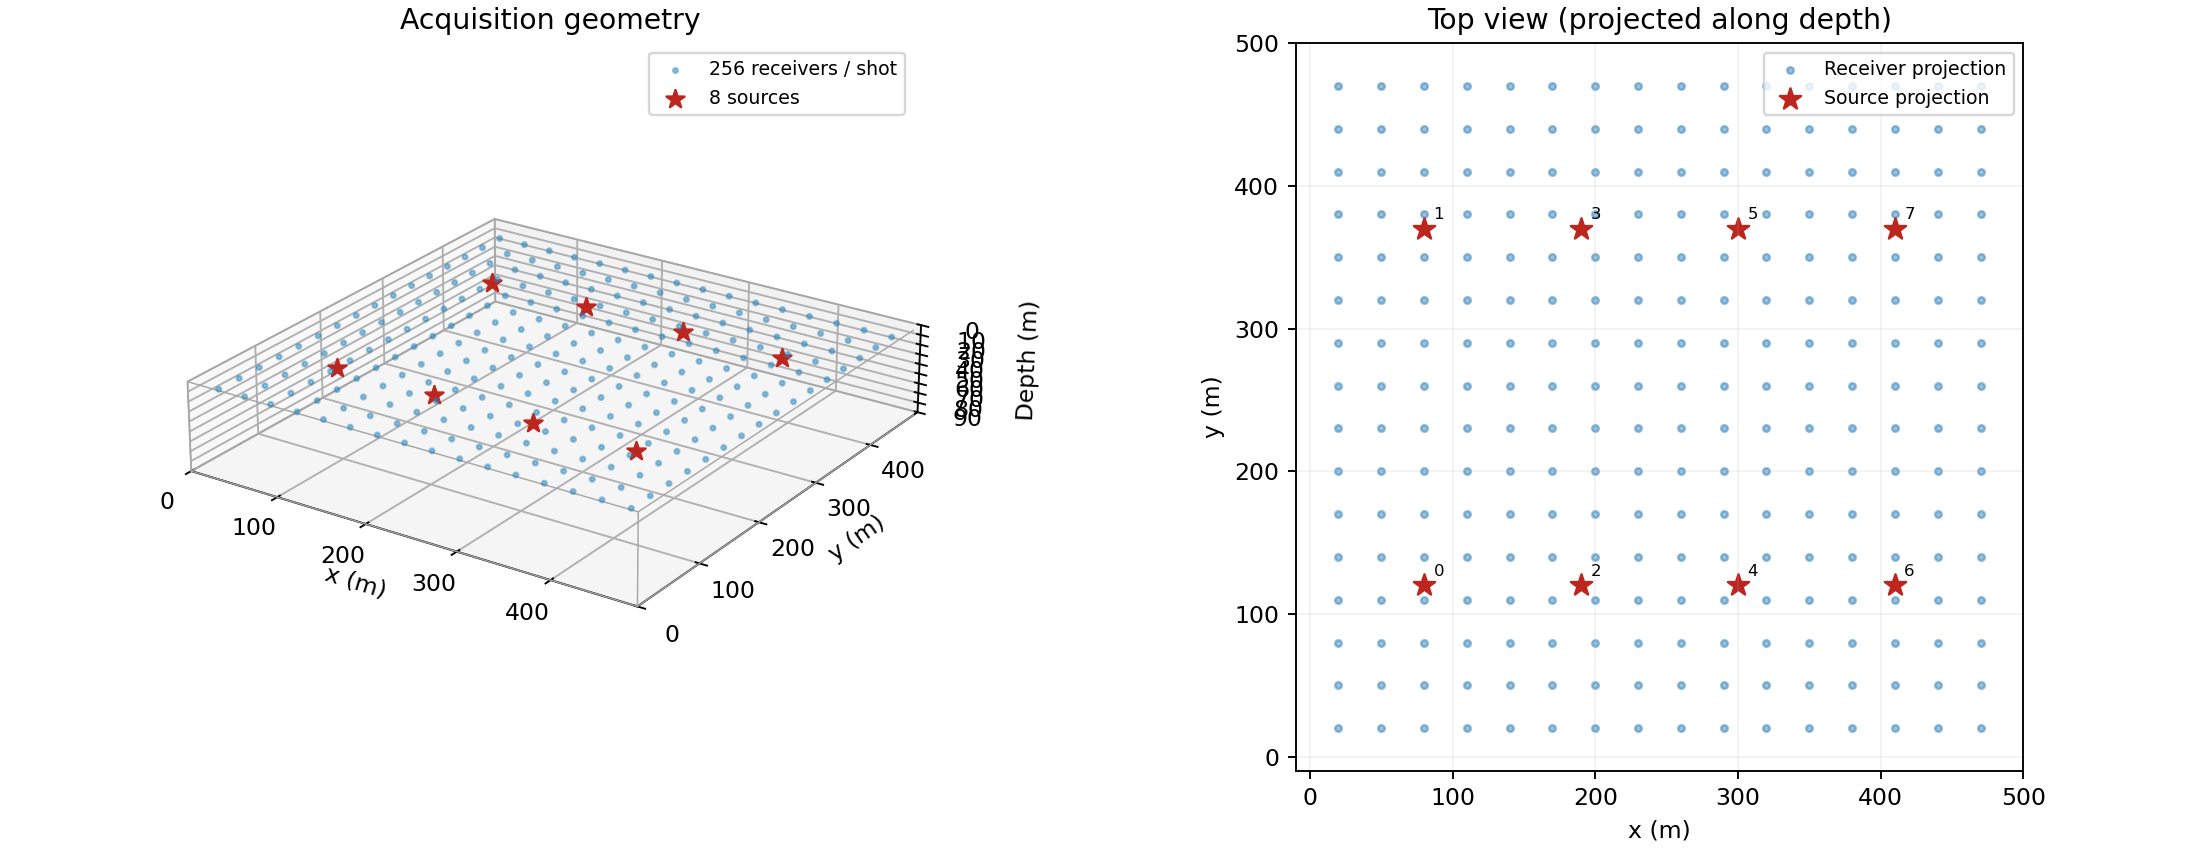

In [26]:
display(Image(filename=str(RESULTS / 'acquisition.png')))

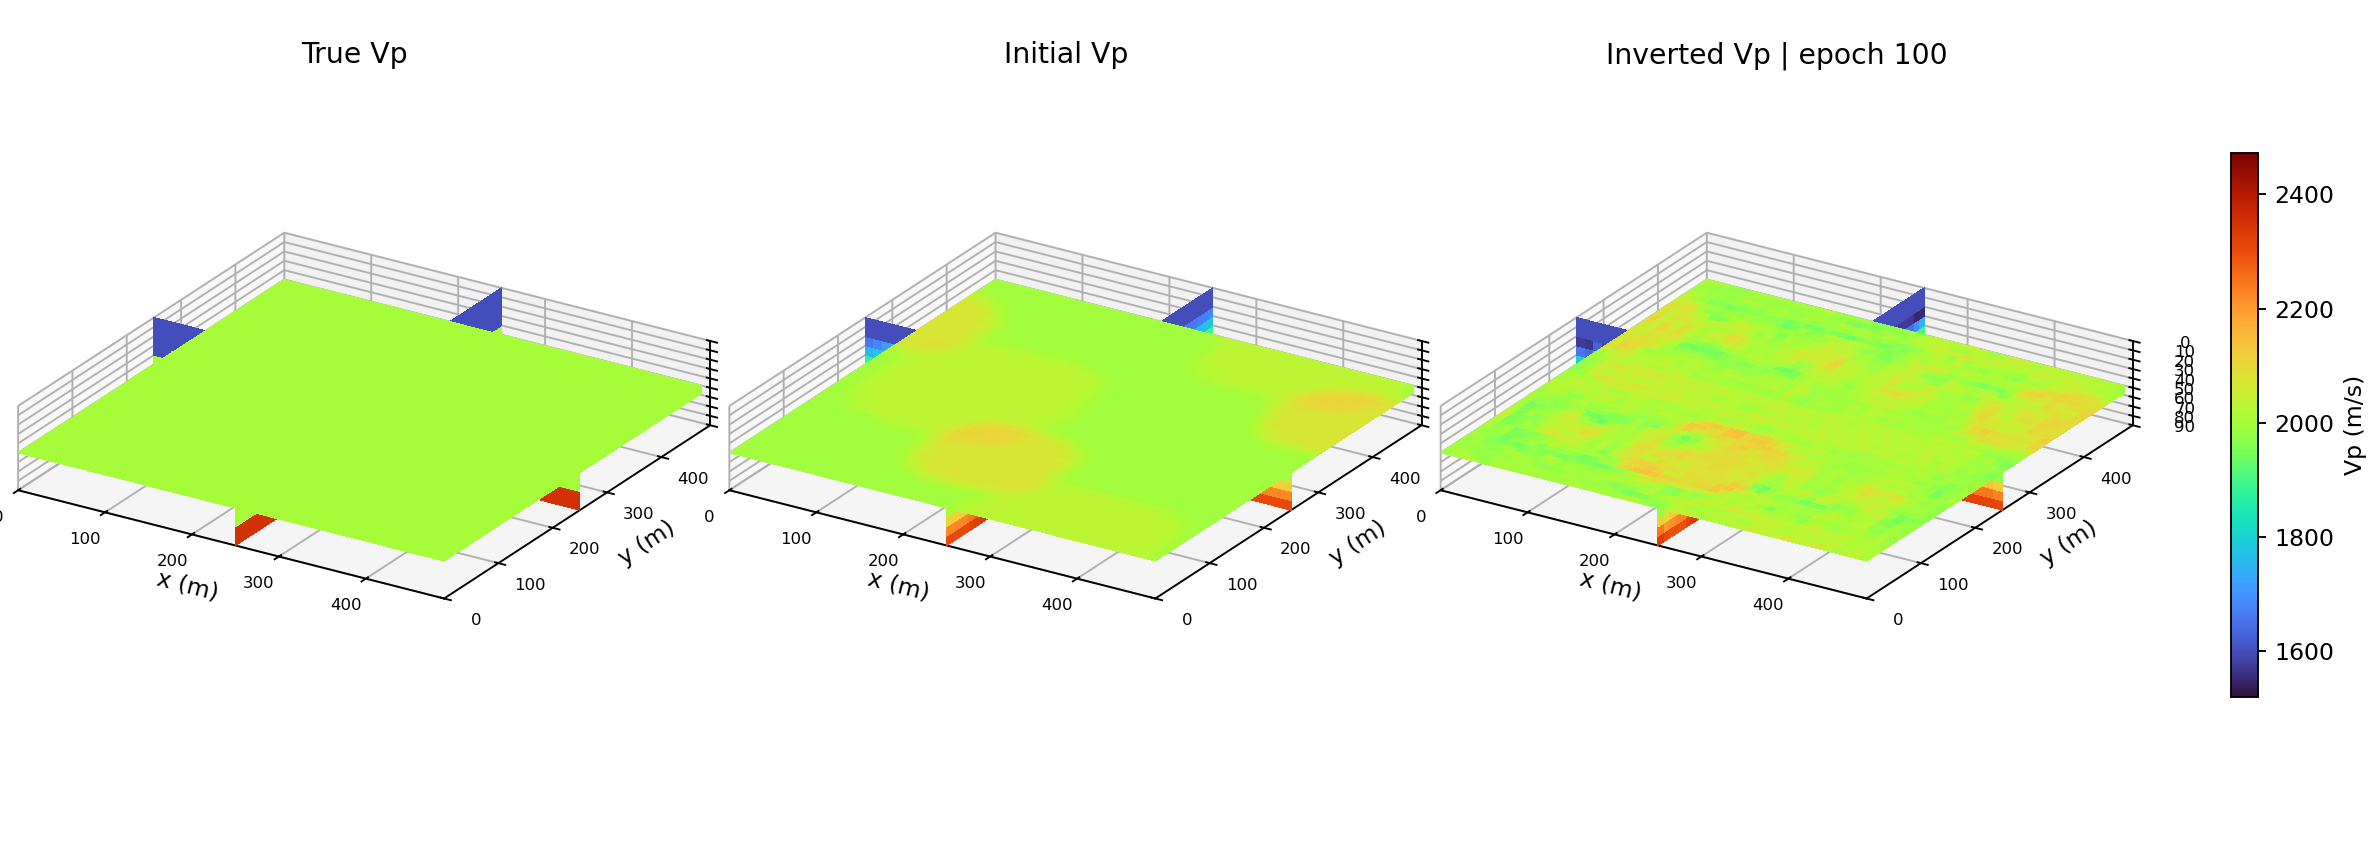

In [27]:
display(Image(filename=str(RESULTS / 'model_3d.png')))

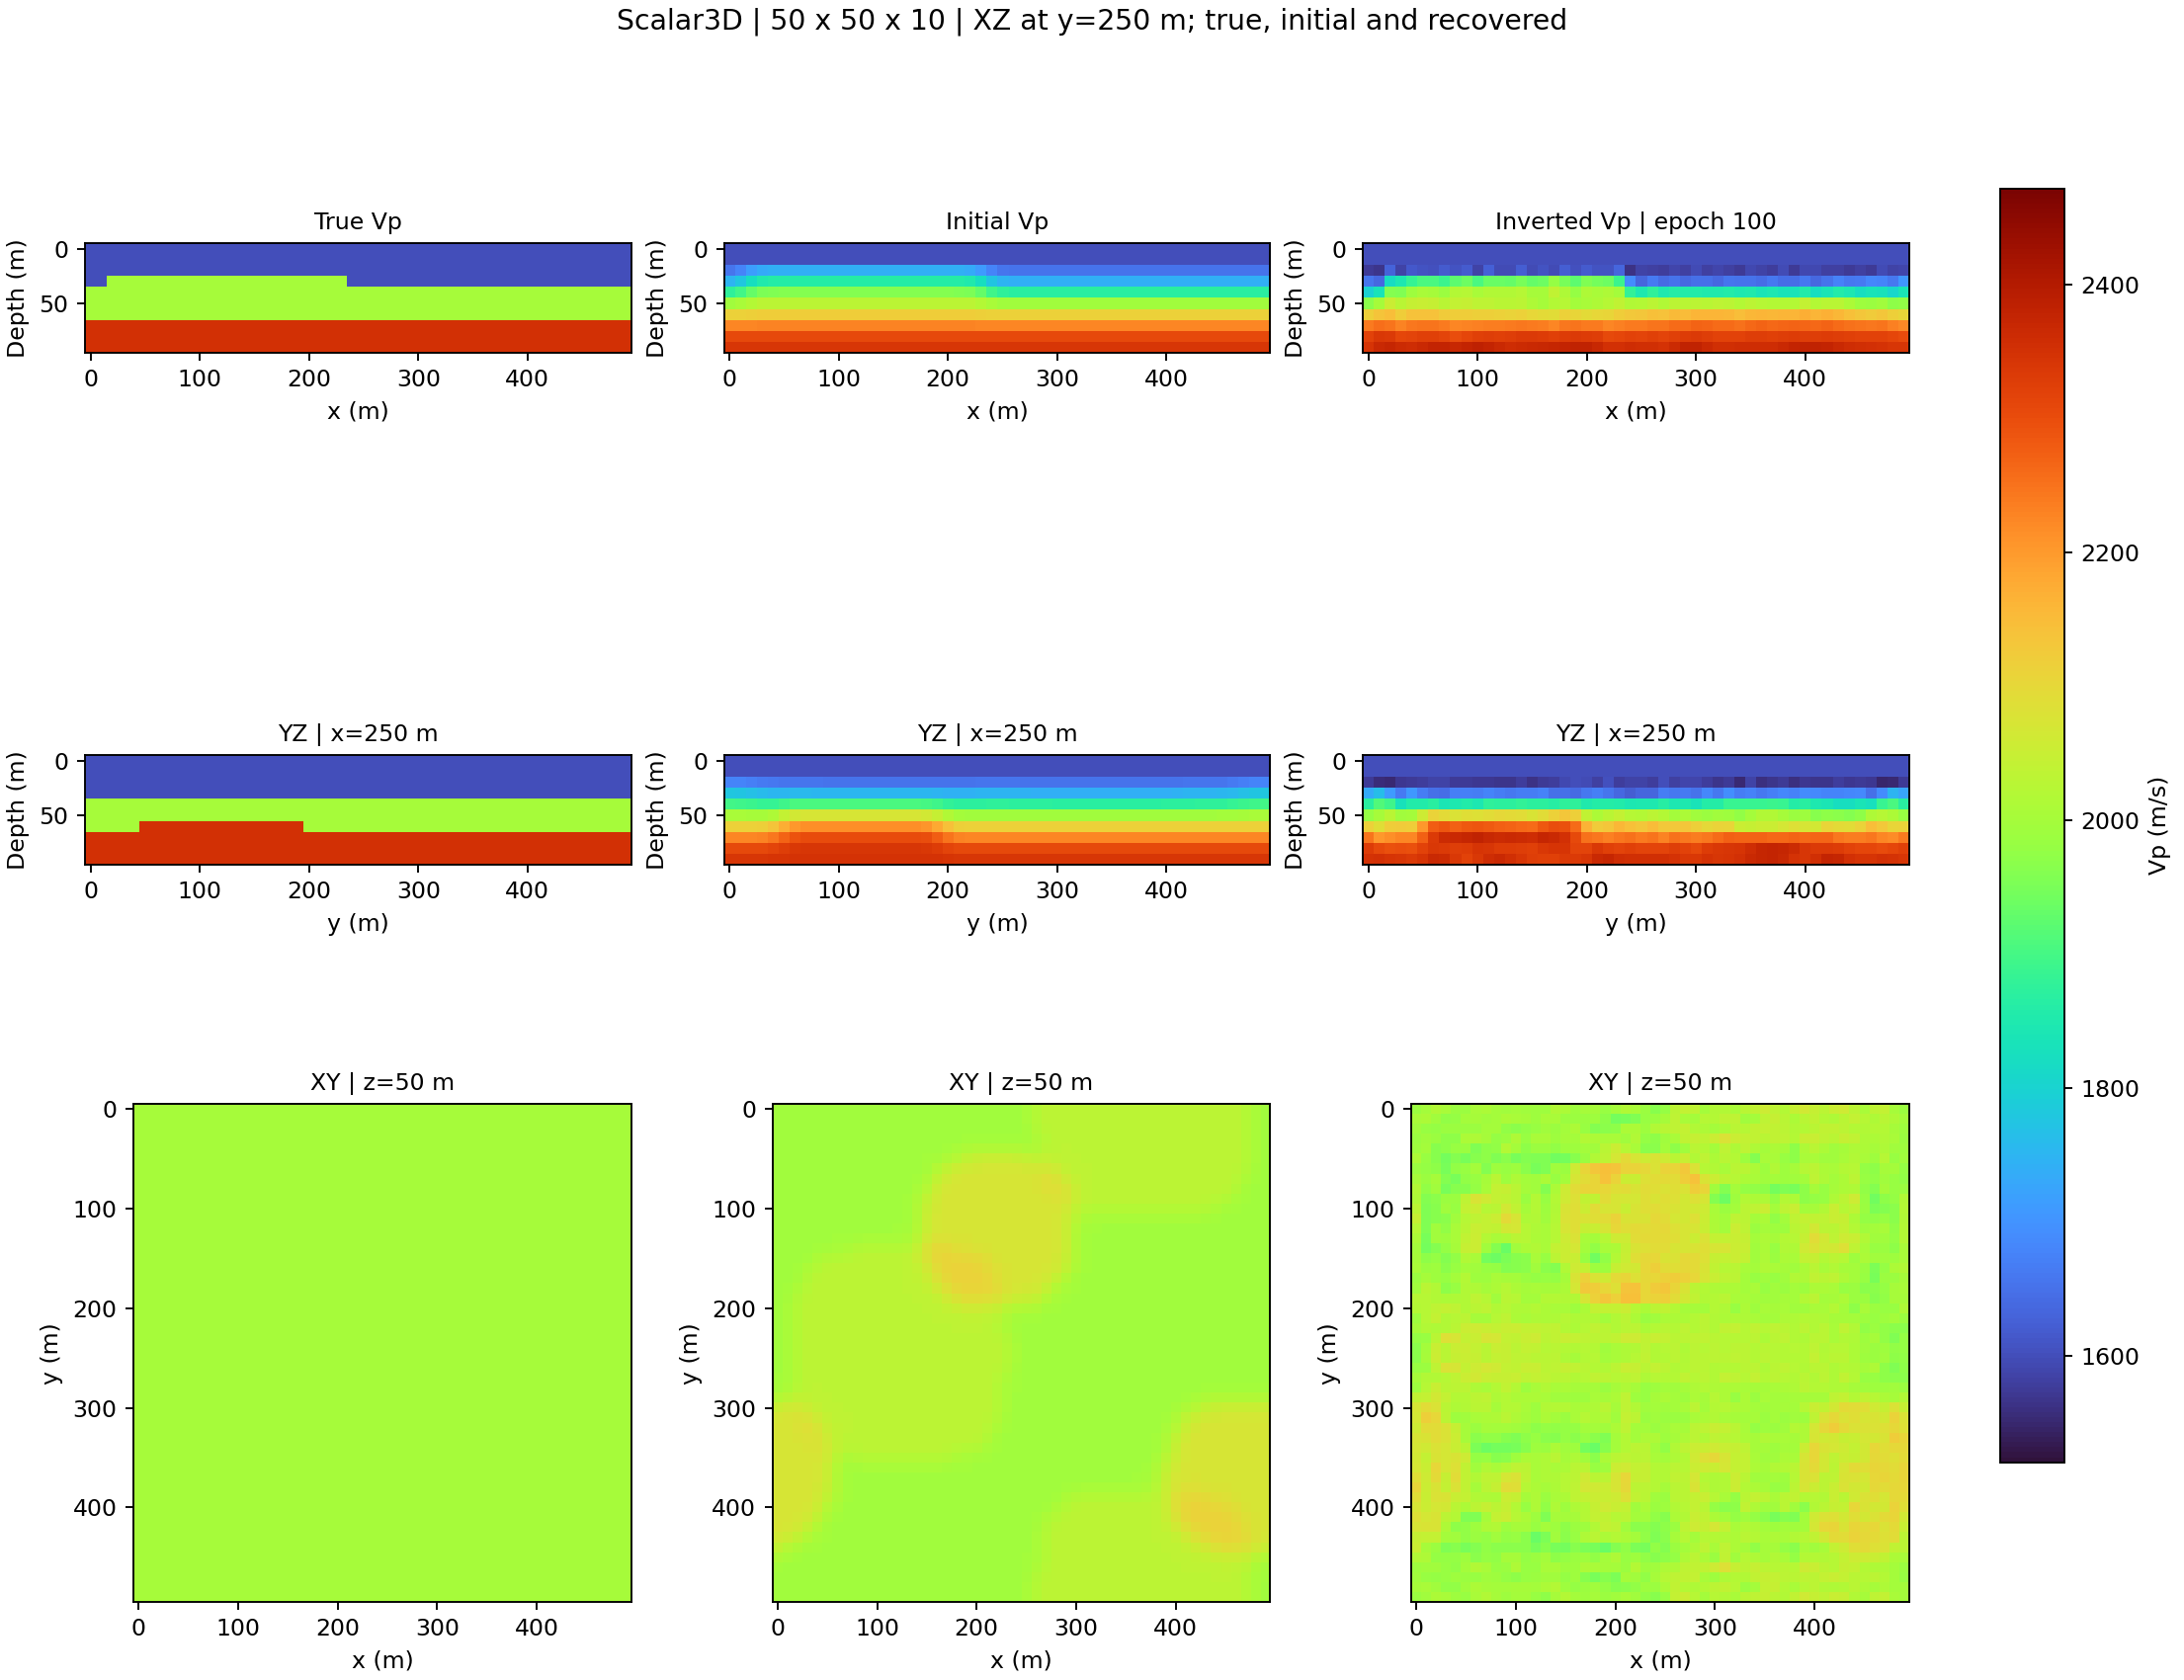

In [28]:
display(Image(filename=str(RESULTS / 'model_comparison.png')))

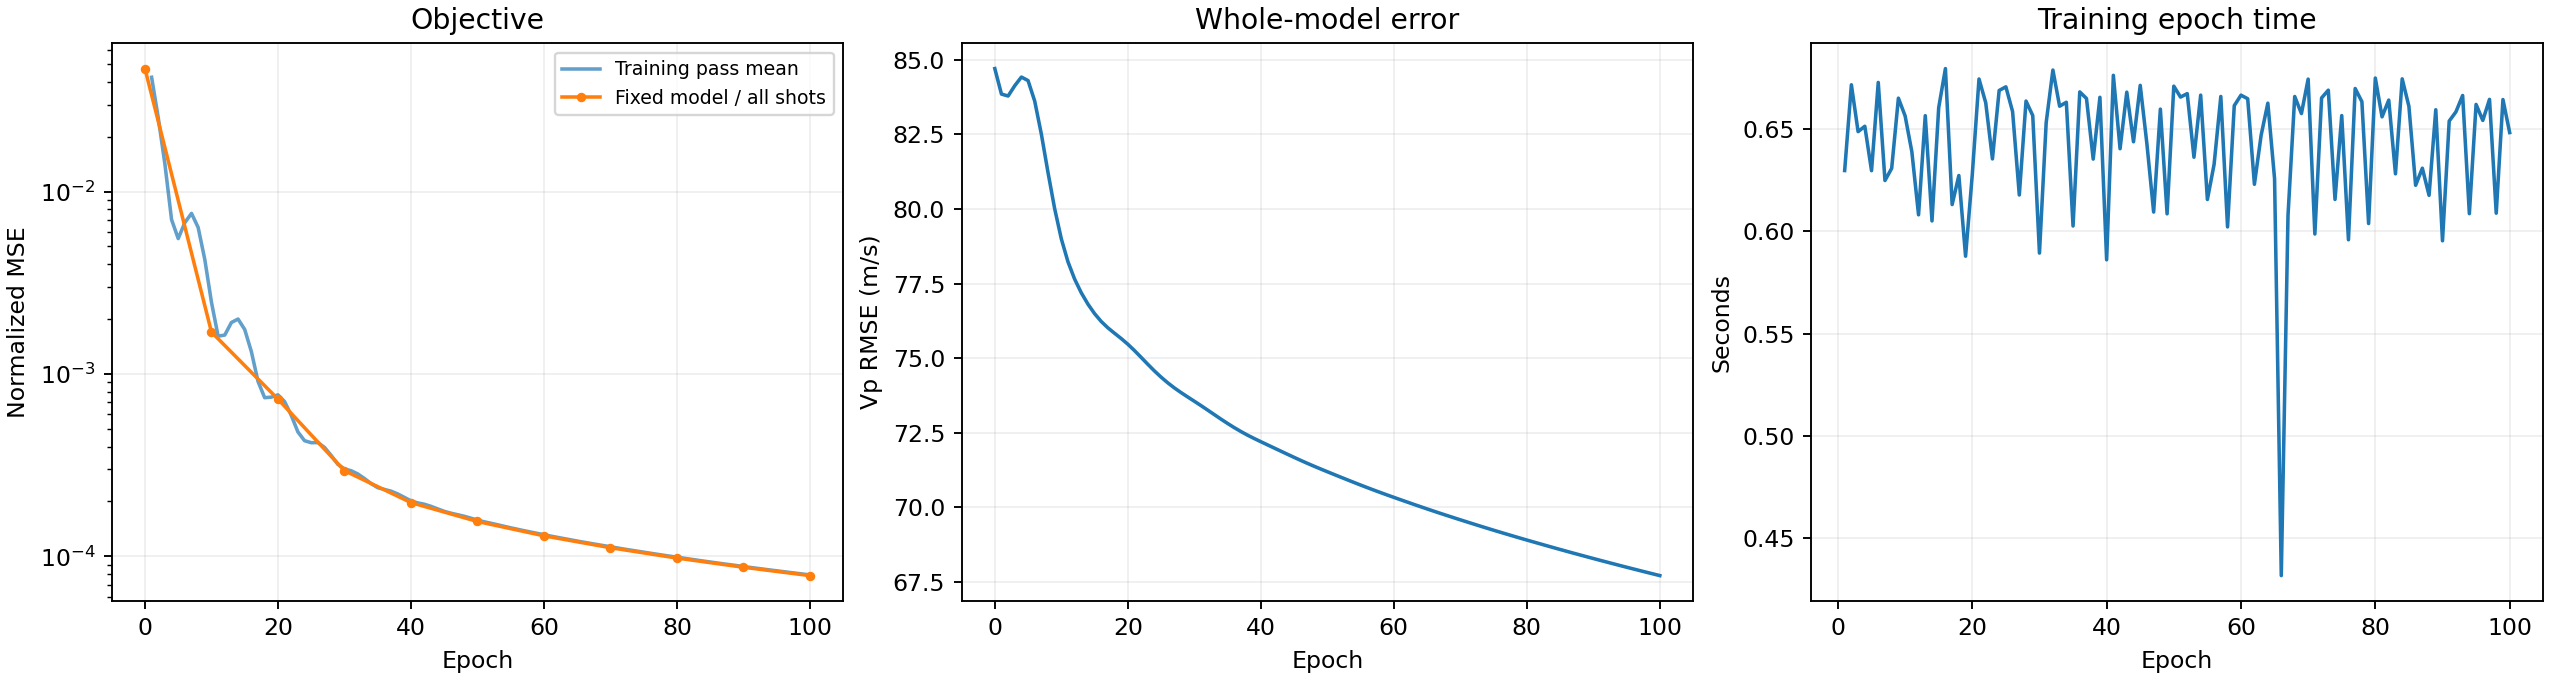

In [29]:
display(Image(filename=str(RESULTS / 'convergence.png')))

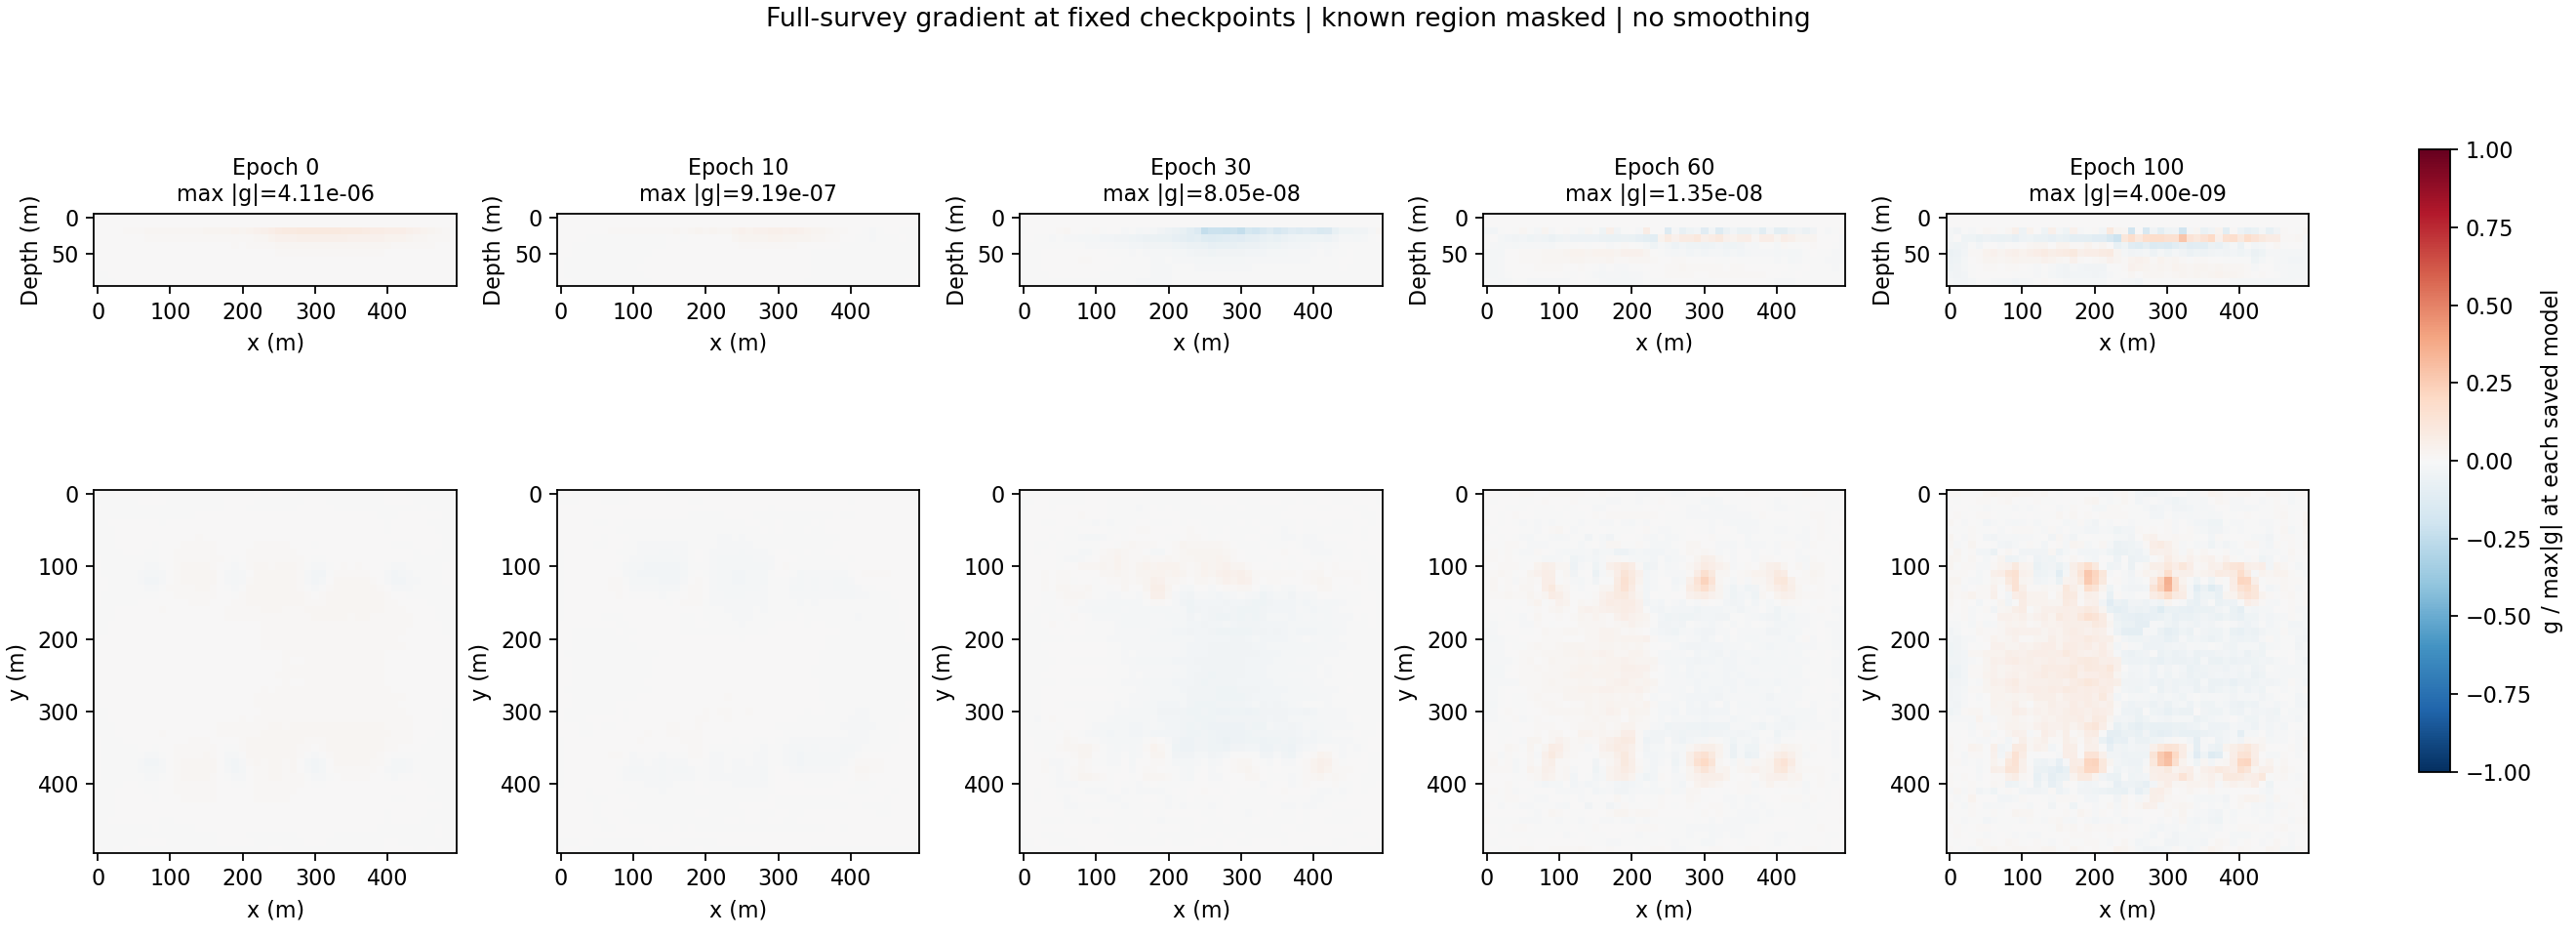

In [30]:
display(Image(filename=str(RESULTS / 'gradients_normalized.png')))

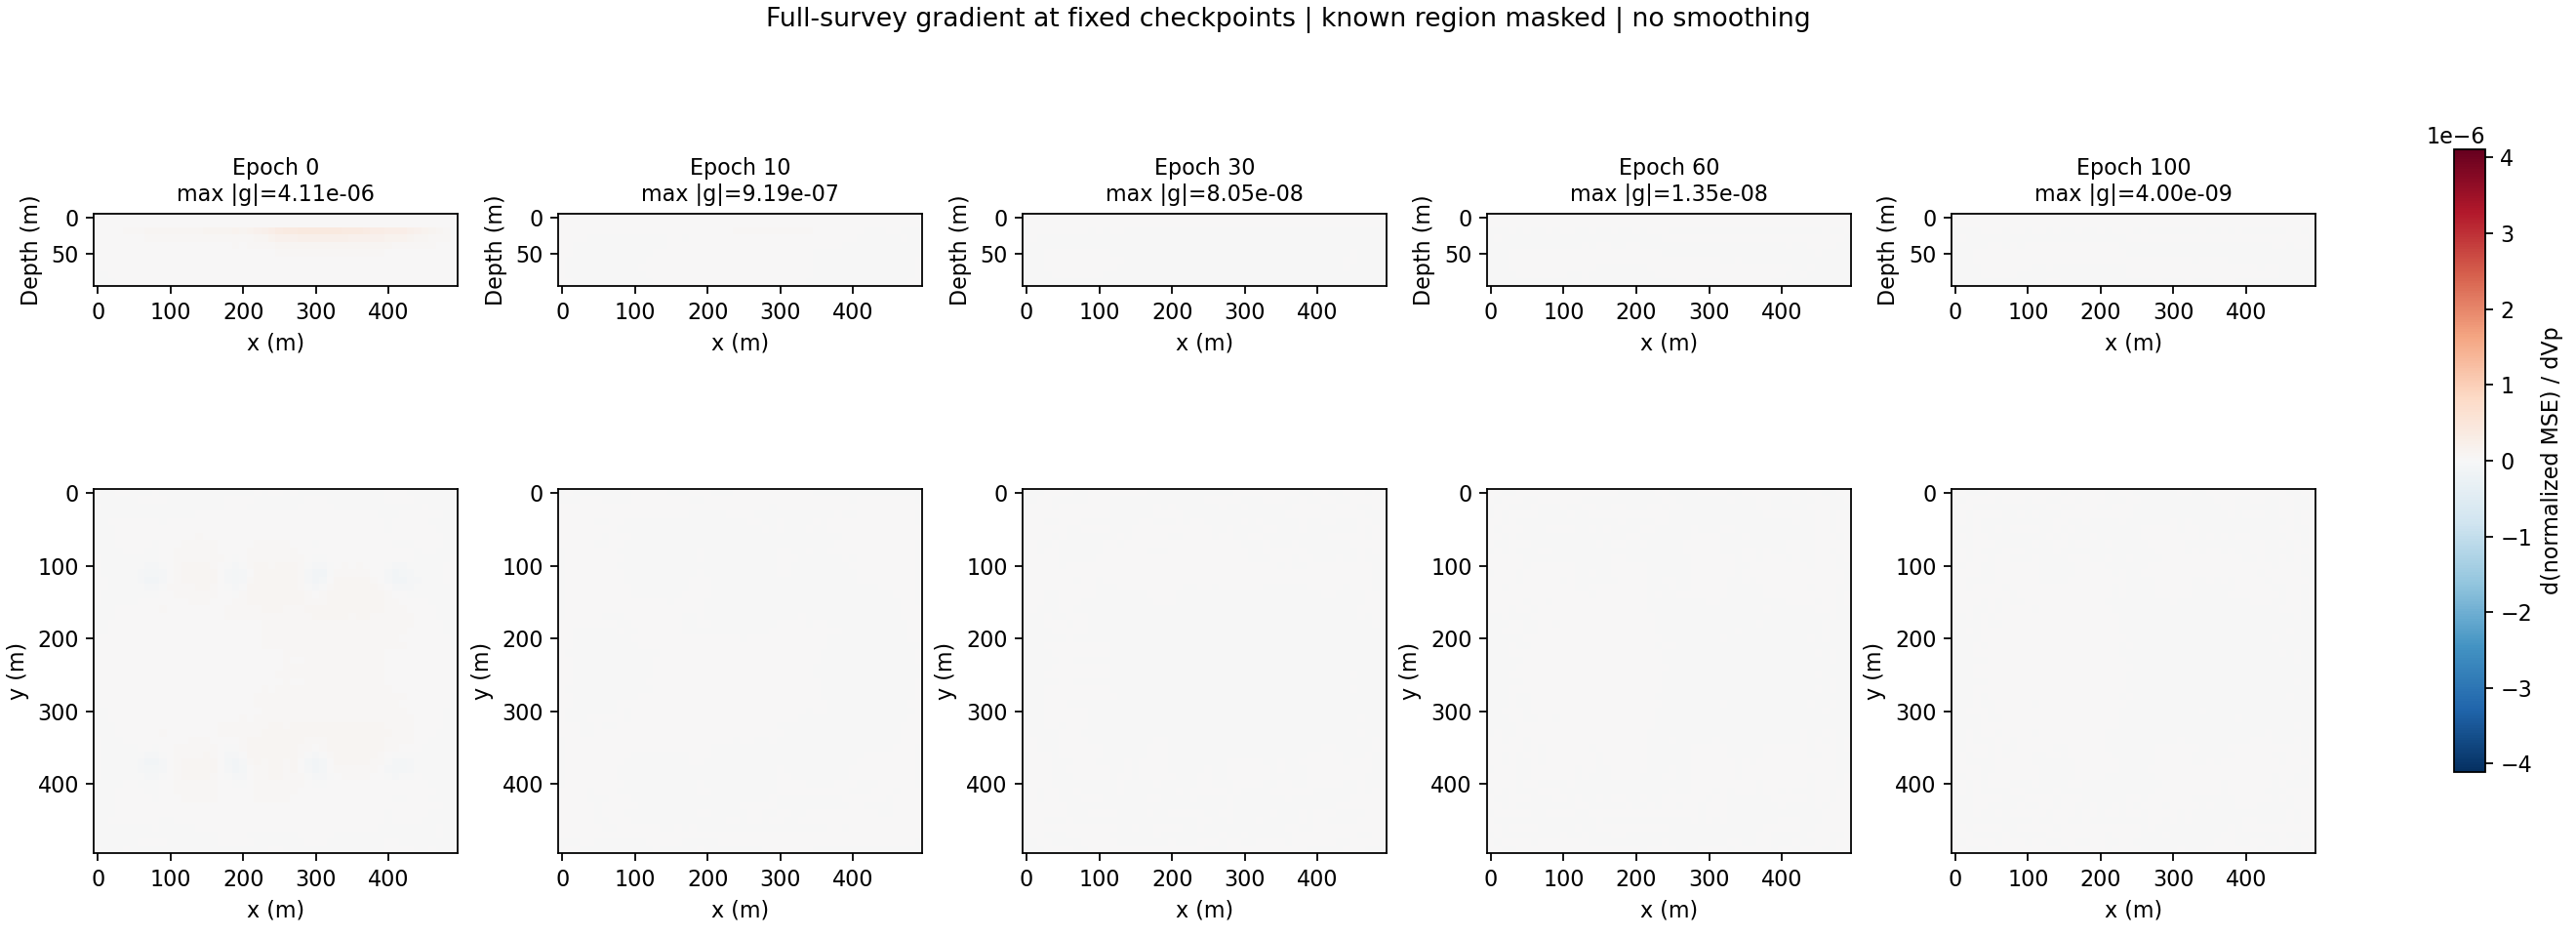

In [31]:
display(Image(filename=str(RESULTS / 'gradients_shared_scale.png')))

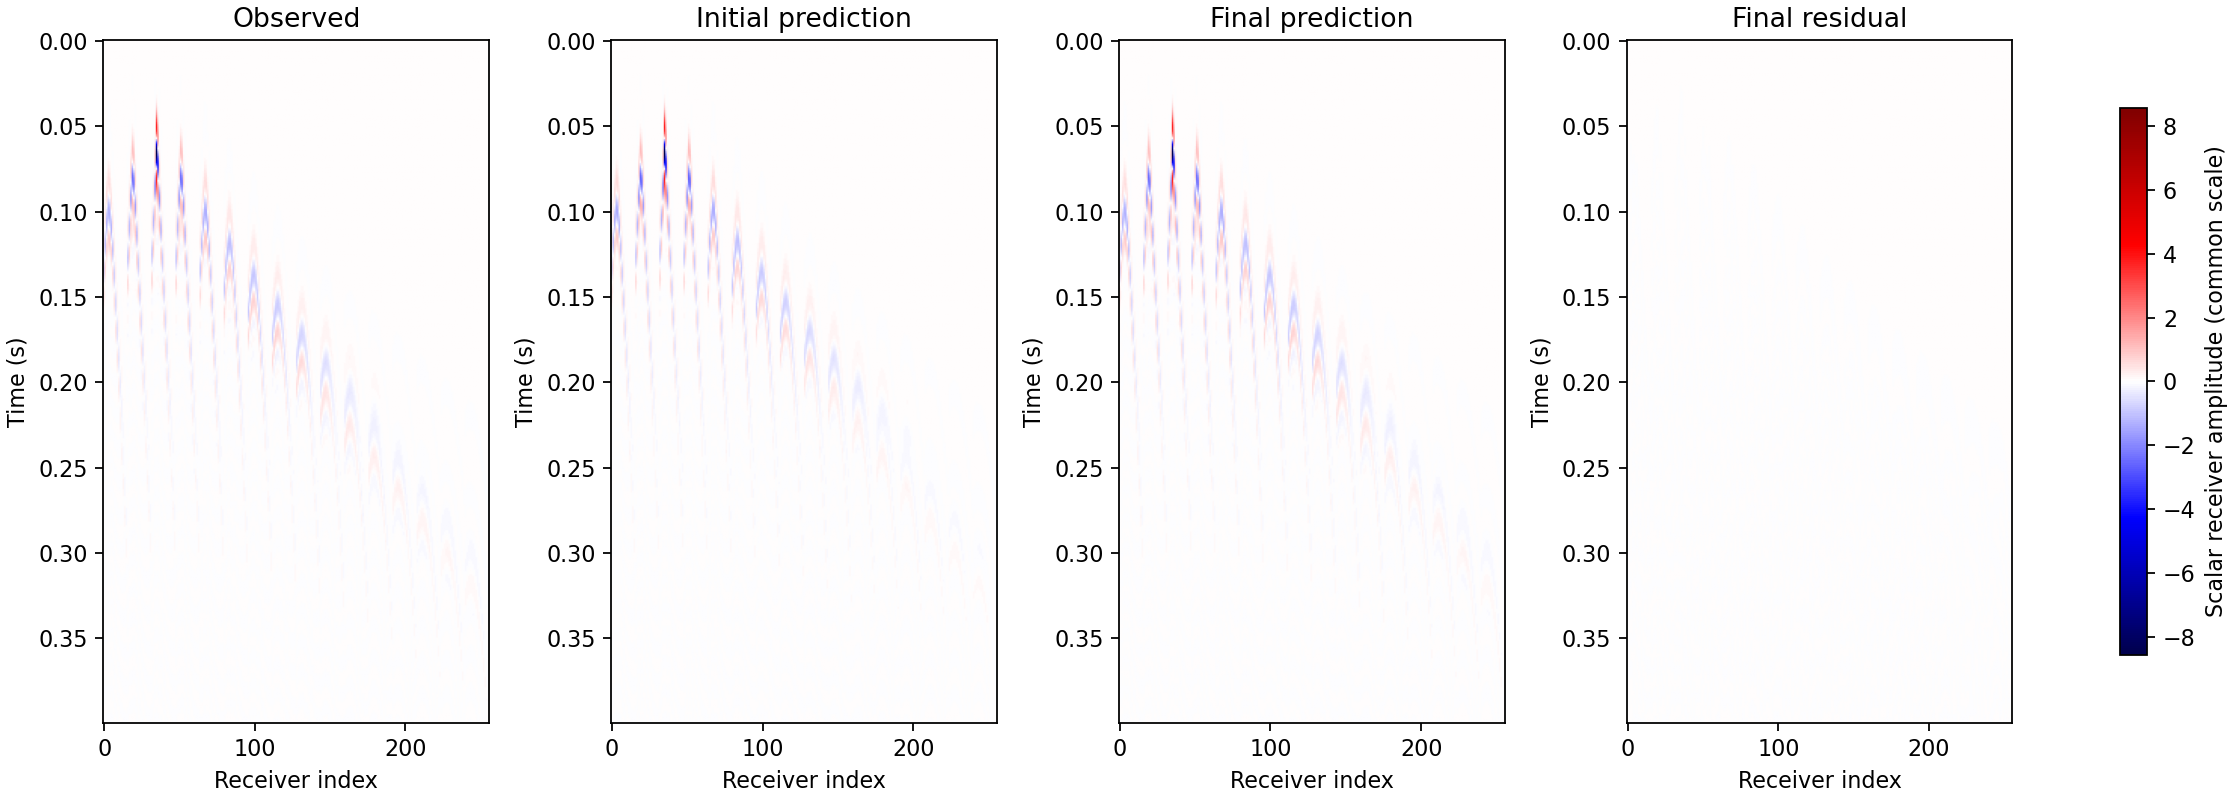

In [32]:
display(Image(filename=str(RESULTS / 'shot_gather.png')))

## 可选：完整CUDA重跑

默认关闭，避免打开报告就开始训练。设置已编译V11路径、新输出目录和GPU_IDS，然后把RUN_FWI改True。不会自动安装、编译或覆盖已有结果。

In [33]:
RUN_FWI = False
SOURCE_ROOT = Path('/path/to/compiled/StarWave')
GPU_IDS = '2,0,1,3'
NEW_RESULTS = ROOT / ('rerun_' + CASE)
if RUN_FWI:
    import subprocess, sys
    subprocess.run([sys.executable,str(ROOT/'run_scalar3d_example.py'),'--case',CASE,
                    '--source-root',str(SOURCE_ROOT),'--output-dir',str(NEW_RESULTS),
                    '--gpu-ids',GPU_IDS],check=True)
else:
    print('Saved-result cells executed. Optional CUDA re-run disabled.')

Saved-result cells executed. Optional CUDA re-run disabled.
